# Training and Inference — UNeXt on the ISIC dataset

This notebook:
1. Loads the train/val/test IDs generated in the preprocessing notebook ISIC
2. Trains the UNeXt model with **512×512 input** and BCEDiceLoss
3. Saves the best model (best validation IoU)
4. Runs inference on the validation and test sets
5. Saves the **probabilities** (after sigmoid) in `.npz` files in the `data/` folder with key `p_hat`

> **Prerequisite:** run `03_preprocessing_ISIC.ipynb` before this notebook.

In [1]:
import os
import sys
import math
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data
from torch.optim import lr_scheduler
from collections import OrderedDict

import pandas as pd
from tqdm import tqdm

import albumentations as A
from albumentations.augmentations import transforms as AT
from albumentations.core.composition import Compose
from albumentations import RandomRotate90, Resize

BASE_DIR  = "./"
UNEXT_DIR = os.path.join(BASE_DIR, "UNeXt-pytorch-main")
if UNEXT_DIR not in sys.path:
    sys.path.insert(0, UNEXT_DIR)

from losses  import BCEDiceLoss
from metrics import iou_score
from utils   import AverageMeter

print(f'PyTorch   : {torch.__version__}')
print(f'CUDA avail.: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU       : {torch.cuda.get_device_name(0)}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

/home/bruno-borges/miniconda3/envs/unext/lib/python3.6/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch   : 1.9.1+cu111
CUDA avail.: True
GPU       : NVIDIA GeForce RTX 3090
Dispositivo: cuda


## UNeXt model definition (512×512)

Defined directly in the notebook to avoid dependency on `mmcv`.

In [2]:
from timm.models.layers import DropPath, to_2tuple, trunc_normal_


class DWConv(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, 3, 1, 1, bias=True, groups=dim)

    def forward(self, x, H, W):
        B, N, C = x.shape
        x = x.transpose(1, 2).view(B, C, H, W)
        x = self.dwconv(x)
        return x.flatten(2).transpose(1, 2)


class shiftmlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None,
                 act_layer=nn.GELU, drop=0., shift_size=5):
        super().__init__()
        out_features    = out_features    or in_features
        hidden_features = hidden_features or in_features
        self.dim        = in_features
        self.fc1        = nn.Linear(in_features, hidden_features)
        self.dwconv     = DWConv(hidden_features)
        self.act        = act_layer()
        self.fc2        = nn.Linear(hidden_features, out_features)
        self.drop       = nn.Dropout(drop)
        self.shift_size = shift_size
        self.pad        = shift_size // 2
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels // m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x, H, W):
        B, N, C = x.shape
        xn = x.transpose(1, 2).view(B, C, H, W).contiguous()
        xn = F.pad(xn, (self.pad,)*4, "constant", 0)
        xs = torch.chunk(xn, self.shift_size, 1)
        x_shift = [torch.roll(xc, s, 2) for xc, s in zip(xs, range(-self.pad, self.pad+1))]
        x_cat   = torch.cat(x_shift, 1)
        x_cat   = torch.narrow(x_cat, 2, self.pad, H)
        x_s     = torch.narrow(x_cat, 3, self.pad, W)
        x_s     = x_s.reshape(B, C, H*W).contiguous().transpose(1, 2)
        x       = self.fc1(x_s)
        x       = self.dwconv(x, H, W)
        x       = self.act(x)
        x       = self.drop(x)
        xn = x.transpose(1, 2).view(B, C, H, W).contiguous()
        xn = F.pad(xn, (self.pad,)*4, "constant", 0)
        xs = torch.chunk(xn, self.shift_size, 1)
        x_shift = [torch.roll(xc, s, 3) for xc, s in zip(xs, range(-self.pad, self.pad+1))]
        x_cat   = torch.cat(x_shift, 1)
        x_cat   = torch.narrow(x_cat, 2, self.pad, H)
        x_s     = torch.narrow(x_cat, 3, self.pad, W)
        x_s     = x_s.reshape(B, C, H*W).contiguous().transpose(1, 2)
        x       = self.fc2(x_s)
        return self.drop(x)


class shiftedBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, qk_scale=None,
                 drop=0., attn_drop=0., drop_path=0., act_layer=nn.GELU,
                 norm_layer=nn.LayerNorm, sr_ratio=1):
        super().__init__()
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2     = norm_layer(dim)
        self.mlp       = shiftmlp(in_features=dim,
                                  hidden_features=int(dim * mlp_ratio),
                                  act_layer=act_layer, drop=drop)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels // m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x, H, W):
        return x + self.drop_path(self.mlp(self.norm2(x), H, W))


class OverlapPatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=7, stride=4, in_chans=3, embed_dim=768):
        super().__init__()
        img_size   = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)
        self.proj  = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size,
                               stride=stride,
                               padding=(patch_size[0]//2, patch_size[1]//2))
        self.norm  = nn.LayerNorm(embed_dim)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels // m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x):
        x = self.proj(x)
        _, _, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        return self.norm(x), H, W


class UNext(nn.Module):
    """UNeXt: Conv 3 + shifted MLP 2."""

    def __init__(self, num_classes, input_channels=3, deep_supervision=False,
                 img_size=512, embed_dims=[128, 160, 256],
                 num_heads=[1, 2, 4, 8], mlp_ratios=[4, 4, 4, 4],
                 qkv_bias=False, qk_scale=None, drop_rate=0.,
                 attn_drop_rate=0., drop_path_rate=0.,
                 norm_layer=nn.LayerNorm, depths=[1, 1, 1],
                 sr_ratios=[8, 4, 2, 1], **kwargs):
        super().__init__()

        self.encoder1 = nn.Conv2d(3,   16,  3, stride=1, padding=1)
        self.encoder2 = nn.Conv2d(16,  32,  3, stride=1, padding=1)
        self.encoder3 = nn.Conv2d(32, 128,  3, stride=1, padding=1)
        self.ebn1 = nn.BatchNorm2d(16)
        self.ebn2 = nn.BatchNorm2d(32)
        self.ebn3 = nn.BatchNorm2d(128)

        self.norm3  = norm_layer(embed_dims[1])
        self.norm4  = norm_layer(embed_dims[2])
        self.dnorm3 = norm_layer(160)
        self.dnorm4 = norm_layer(128)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]

        self.block1  = nn.ModuleList([shiftedBlock(embed_dims[1], num_heads[0], mlp_ratio=1,
                                                   drop=drop_rate, attn_drop=attn_drop_rate,
                                                   drop_path=dpr[0], norm_layer=norm_layer)])
        self.block2  = nn.ModuleList([shiftedBlock(embed_dims[2], num_heads[0], mlp_ratio=1,
                                                   drop=drop_rate, attn_drop=attn_drop_rate,
                                                   drop_path=dpr[1], norm_layer=norm_layer)])
        self.dblock1 = nn.ModuleList([shiftedBlock(embed_dims[1], num_heads[0], mlp_ratio=1,
                                                   drop=drop_rate, attn_drop=attn_drop_rate,
                                                   drop_path=dpr[0], norm_layer=norm_layer)])
        self.dblock2 = nn.ModuleList([shiftedBlock(embed_dims[0], num_heads[0], mlp_ratio=1,
                                                   drop=drop_rate, attn_drop=attn_drop_rate,
                                                   drop_path=dpr[1], norm_layer=norm_layer)])

        self.patch_embed3 = OverlapPatchEmbed(img_size=img_size//4,  patch_size=3,
                                              stride=2, in_chans=embed_dims[0],
                                              embed_dim=embed_dims[1])
        self.patch_embed4 = OverlapPatchEmbed(img_size=img_size//8,  patch_size=3,
                                              stride=2, in_chans=embed_dims[1],
                                              embed_dim=embed_dims[2])

        self.decoder1 = nn.Conv2d(256, 160, 3, stride=1, padding=1)
        self.decoder2 = nn.Conv2d(160, 128, 3, stride=1, padding=1)
        self.decoder3 = nn.Conv2d(128,  32, 3, stride=1, padding=1)
        self.decoder4 = nn.Conv2d(32,   16, 3, stride=1, padding=1)
        self.decoder5 = nn.Conv2d(16,   16, 3, stride=1, padding=1)
        self.dbn1 = nn.BatchNorm2d(160)
        self.dbn2 = nn.BatchNorm2d(128)
        self.dbn3 = nn.BatchNorm2d(32)
        self.dbn4 = nn.BatchNorm2d(16)

        self.final = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x):
        B = x.shape[0]
        out = F.relu(F.max_pool2d(self.ebn1(self.encoder1(x)), 2, 2)); t1 = out
        out = F.relu(F.max_pool2d(self.ebn2(self.encoder2(out)), 2, 2)); t2 = out
        out = F.relu(F.max_pool2d(self.ebn3(self.encoder3(out)), 2, 2)); t3 = out

        out, H, W = self.patch_embed3(out)
        for blk in self.block1:
            out = blk(out, H, W)
        out = self.norm3(out).reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous(); t4 = out

        out, H, W = self.patch_embed4(out)
        for blk in self.block2:
            out = blk(out, H, W)
        out = self.norm4(out).reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()

        out = F.relu(F.interpolate(self.dbn1(self.decoder1(out)), scale_factor=2, mode='bilinear', align_corners=False))
        out = torch.add(out, t4)
        _, _, H, W = out.shape
        out = out.flatten(2).transpose(1, 2)
        for blk in self.dblock1:
            out = blk(out, H, W)

        out = self.dnorm3(out).reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
        out = F.relu(F.interpolate(self.dbn2(self.decoder2(out)), scale_factor=2, mode='bilinear', align_corners=False))
        out = torch.add(out, t3)
        _, _, H, W = out.shape
        out = out.flatten(2).transpose(1, 2)
        for blk in self.dblock2:
            out = blk(out, H, W)

        out = self.dnorm4(out).reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
        out = F.relu(F.interpolate(self.dbn3(self.decoder3(out)), scale_factor=2, mode='bilinear', align_corners=False))
        out = torch.add(out, t2)
        out = F.relu(F.interpolate(self.dbn4(self.decoder4(out)), scale_factor=2, mode='bilinear', align_corners=False))
        out = torch.add(out, t1)
        out = F.relu(F.interpolate(self.decoder5(out), scale_factor=2, mode='bilinear', align_corners=False))
        return self.final(out)


print('UNeXt model (512×512) defined.')

Modelo UNeXt (512×512) definido.


In [3]:
# ─── Configuration ─────────────────────────────────────────────────────────────
config = {
    'dataset'       : 'ISIC',
    'img_ext'       : '.png',
    'mask_ext'      : '.png',
    'num_classes'   : 1,
    'input_channels': 3,

    # Input resolution — must match preprocessing size (512)
    # 512 is divisible by 32, compatible with UNeXt
    'input_h': 512,
    'input_w': 512,

    'epochs'         : 400,
    'batch_size'     : 8,    # smaller batch due to 512×512 resolution
    'num_workers'    : 4,
    'lr'             : 1e-4,
    'weight_decay'   : 1e-4,
    'deep_supervision': False,
    'early_stopping' : 20,

    'inputs_dir' : os.path.join(UNEXT_DIR, 'inputs', 'ISIC'),
    'models_dir' : os.path.join(BASE_DIR,  'models', 'UNeXt_ISIC'),
    'data_dir'   : os.path.join(BASE_DIR,  'data'),
}

os.makedirs(config['models_dir'], exist_ok=True)
os.makedirs(config['data_dir'],   exist_ok=True)

for k, v in config.items():
    print(f'  {k:20s}: {v}')

  dataset             : ISIC
  img_ext             : .png
  mask_ext            : .png
  num_classes         : 1
  input_channels      : 3
  input_h             : 512
  input_w             : 512
  epochs              : 400
  batch_size          : 8
  num_workers         : 4
  lr                  : 0.0001
  weight_decay        : 0.0001
  deep_supervision    : False
  early_stopping      : 20
  inputs_dir          : ./UNeXt-pytorch-main/inputs/ISIC
  models_dir          : ./models/UNeXt_ISIC
  data_dir            : ./data


In [4]:
# ─── Load split IDs ───────────────────────────────────────────────────
from typing import List

def load_ids(split: str) -> List[str]:
    path = os.path.join(config['inputs_dir'], f'{split}_ids.txt')
    with open(path) as f:
        return [line.strip() for line in f if line.strip()]

train_ids = load_ids('train')
val_ids   = load_ids('val')
test_ids  = load_ids('test')

print(f'Train     : {len(train_ids)}')
print(f'Validation: {len(val_ids)}')
print(f'Test      : {len(test_ids)}')

Treino    : 2155
Validation: 539
Teste     : 1000


In [5]:
# ─── Dataset ──────────────────────────────────────────────────────────────────
class ISICDataset(torch.utils.data.Dataset):
    """Dataset ISIC no formato UNeXt (images/ e masks/0/)."""

    def __init__(self, img_ids, img_dir, mask_dir, img_ext, mask_ext,
                 num_classes, transform=None):
        self.img_ids     = img_ids
        self.img_dir     = img_dir
        self.mask_dir    = mask_dir
        self.img_ext     = img_ext
        self.mask_ext    = mask_ext
        self.num_classes = num_classes
        self.transform   = transform

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]

        img = cv2.imread(os.path.join(self.img_dir, img_id + self.img_ext))

        mask = []
        for c in range(self.num_classes):
            m = cv2.imread(
                os.path.join(self.mask_dir, str(c), img_id + self.mask_ext),
                cv2.IMREAD_GRAYSCALE
            )
            mask.append(m[..., None])
        mask = np.dstack(mask)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']
            mask = aug['mask']

        img  = img.astype('float32') / 255   # matches original UNeXt dataset.py
        img  = img.transpose(2, 0, 1)        # (C, H, W)
        mask = mask.astype('float32') / 255
        mask = mask.transpose(2, 0, 1)       # (1, H, W)

        return img, mask, {'img_id': img_id}


# Transforms — match original UNeXt train.py exactly
train_transform = Compose([
    RandomRotate90(),
    AT.Flip(),
    Resize(config['input_h'], config['input_w']),
    AT.Normalize(),
])

val_transform = Compose([
    Resize(config['input_h'], config['input_w']),
    AT.Normalize(),
])

img_dir  = os.path.join(config['inputs_dir'], 'images')
mask_dir = os.path.join(config['inputs_dir'], 'masks')

train_ds = ISICDataset(train_ids, img_dir, mask_dir,
                       config['img_ext'], config['mask_ext'],
                       config['num_classes'], train_transform)
val_ds   = ISICDataset(val_ids,   img_dir, mask_dir,
                       config['img_ext'], config['mask_ext'],
                       config['num_classes'], val_transform)
test_ds  = ISICDataset(test_ids,  img_dir, mask_dir,
                       config['img_ext'], config['mask_ext'],
                       config['num_classes'], val_transform)

train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=config['batch_size'], shuffle=True,
    num_workers=config['num_workers'], drop_last=True, pin_memory=True)
val_loader   = torch.utils.data.DataLoader(
    val_ds,   batch_size=config['batch_size'], shuffle=False,
    num_workers=config['num_workers'], pin_memory=True)
test_loader  = torch.utils.data.DataLoader(
    test_ds,  batch_size=1, shuffle=False,
    num_workers=config['num_workers'], pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')
print(f'Test  batches: {len(test_loader)}')

Train batches: 269
Val   batches: 68
Test  batches: 1000


In [6]:
# ─── Model, criterion, optimizer and scheduler ─────────────────────────────────
import torch.backends.cudnn as cudnn
cudnn.benchmark = True   # matches original UNeXt train.py

model     = UNext(num_classes=config['num_classes'],
                  input_channels=config['input_channels'],
                  img_size=config['input_h']).to(DEVICE)
criterion = BCEDiceLoss().to(DEVICE)
optimizer = optim.Adam(model.parameters(),
                       lr=config['lr'],
                       weight_decay=config['weight_decay'],
                       betas=(0.9, 0.999))
scheduler = lr_scheduler.CosineAnnealingLR(optimizer,
                                           T_max=config['epochs'],
                                           eta_min=1e-5)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Trainable parameters: 1,471,921


In [7]:
# ─── Training and validation functions ───────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    meters = {'loss': AverageMeter(), 'iou': AverageMeter()}
    pbar   = tqdm(loader, desc='  Train', leave=False)
    for imgs, masks, _ in pbar:
        imgs, masks = imgs.to(device), masks.to(device)
        out  = model(imgs)
        loss = criterion(out, masks)
        iou, _ = iou_score(out, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        meters['loss'].update(loss.item(), imgs.size(0))
        meters['iou'].update(iou, imgs.size(0))
        pbar.set_postfix(loss=f'{meters["loss"].avg:.4f}', iou=f'{meters["iou"].avg:.4f}')
    return {k: v.avg for k, v in meters.items()}


def val_epoch(model, loader, criterion, device):
    model.eval()
    meters = {'loss': AverageMeter(), 'iou': AverageMeter(), 'dice': AverageMeter()}
    pbar   = tqdm(loader, desc='  Val  ', leave=False)
    with torch.no_grad():
        for imgs, masks, _ in pbar:
            imgs, masks = imgs.to(device), masks.to(device)
            out  = model(imgs)
            loss = criterion(out, masks)
            iou, dice = iou_score(out, masks)
            meters['loss'].update(loss.item(), imgs.size(0))
            meters['iou'].update(iou, imgs.size(0))
            meters['dice'].update(dice, imgs.size(0))
            pbar.set_postfix(iou=f'{meters["iou"].avg:.4f}', dice=f'{meters["dice"].avg:.4f}')
    return {k: v.avg for k, v in meters.items()}


print('Training functions defined.')

Training functions defined.


In [8]:
# ─── Training loop ──────────────────────────────────────────────────────
best_iou   = 0.0
no_improve = 0
log_rows   = []
model_path = os.path.join(config['models_dir'], 'best_model.pth')

for epoch in range(1, config['epochs'] + 1):
    train_log = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_log   = val_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step()

    lr_now = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:3d}/{config['epochs']}  "
          f"loss={train_log['loss']:.4f}  iou={train_log['iou']:.4f}  "
          f"val_loss={val_log['loss']:.4f}  val_iou={val_log['iou']:.4f}  "
          f"val_dice={val_log['dice']:.4f}  lr={lr_now:.2e}")

    log_rows.append({'epoch': epoch, 'lr': lr_now,
                     **{f'train_{k}': v for k, v in train_log.items()},
                     **{f'val_{k}':   v for k, v in val_log.items()}})

    if val_log['iou'] > best_iou:
        best_iou   = val_log['iou']
        no_improve = 0
        torch.save(model.state_dict(), model_path)
        print(f'  => Best model saved  (val_iou={best_iou:.4f})')
    else:
        no_improve += 1

    if config['early_stopping'] > 0 and no_improve >= config['early_stopping']:
        print(f'Early stopping triggered at epoch {epoch}.')
        break

    torch.cuda.empty_cache()

log_df = pd.DataFrame(log_rows)
log_df.to_csv(os.path.join(config['models_dir'], 'training_log.csv'), index=False)
print(f'\nTraining complete. Best val_iou = {best_iou:.4f}')
print(f'Model saved at: {model_path}')

Epoch   1/400  loss=0.7348  iou=0.5275  val_loss=0.5778  val_iou=0.5444  val_dice=0.6978  lr=1.00e-04
  => Melhor modelo salvo  (val_iou=0.5444)


Epoch   2/400  loss=0.4463  iou=0.6521  val_loss=0.4128  val_iou=0.6552  val_dice=0.7853  lr=1.00e-04
  => Melhor modelo salvo  (val_iou=0.6552)


Epoch   3/400  loss=0.3948  iou=0.6725  val_loss=0.3893  val_iou=0.6675  val_dice=0.7939  lr=1.00e-04
  => Melhor modelo salvo  (val_iou=0.6675)


Epoch   4/400  loss=0.3536  iou=0.7043  val_loss=0.3998  val_iou=0.6604  val_dice=0.7891  lr=1.00e-04


Epoch   5/400  loss=0.3433  iou=0.7088  val_loss=0.3412  val_iou=0.7064  val_dice=0.8219  lr=1.00e-04
  => Melhor modelo salvo  (val_iou=0.7064)


...

Epoch 159/400  loss=0.1655  iou=0.8409  val_loss=0.2358  val_iou=0.7788  val_dice=0.8724  lr=6.92e-05


Epoch 160/400  loss=0.1636  iou=0.8388  val_loss=0.2131  val_iou=0.7990  val_dice=0.8851  lr=6.89e-05


Epoch 161/400  loss=0.1622  iou=0.8405  val_loss=0.2149  val_iou=0.7939  val_dice=0.8820  lr=6.86e-05


Epoch 162/400  loss=0.1660  iou=0.8386  val_loss=0.2212  val_iou=0.7937  val_dice=0.8816  lr=6.82e-05


Epoch 163/400  loss=0.1643  iou=0.8428  val_loss=0.2160  val_iou=0.7924  val_dice=0.8810  lr=6.79e-05
Early stopping triggered at epoch 163.

Training complete. Best val_iou = 0.7996
Modelo salvo em: ./models/UNeXt_ISIC/best_model.pth


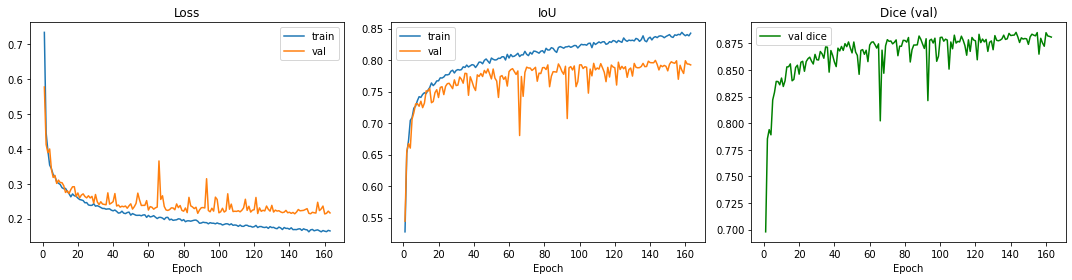

In [9]:
# ─── Learning curves ────────────────────────────────────────────────────
import matplotlib.pyplot as plt

log_df = pd.read_csv(os.path.join(config['models_dir'], 'training_log.csv'))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(log_df['epoch'], log_df['train_loss'], label='train')
axes[0].plot(log_df['epoch'], log_df['val_loss'],   label='val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(log_df['epoch'], log_df['train_iou'], label='train')
axes[1].plot(log_df['epoch'], log_df['val_iou'],   label='val')
axes[1].set_title('IoU'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(log_df['epoch'], log_df['val_dice'], label='val dice', color='green')
axes[2].set_title('Dice (val)'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(os.path.join(config['models_dir'], 'learning_curves.png'), dpi=120)
plt.show()

In [10]:
# ─── Inference — generic function ─────────────────────────────────────────────
def run_inference(model, loader, device, out_dir, split_name):
    """Saves probabilities (after sigmoid) in .npz, key 'p_hat'.

    Each file contains:
      - 'p_hat'  : np.float32, shape (1, H, W), values in [0, 1]
      - 'img_id' : str
    """
    model.eval()
    os.makedirs(out_dir, exist_ok=True)
    ious, dices = [], []

    with torch.no_grad():
        for imgs, masks, meta in tqdm(loader, desc=f'Inference {split_name}'):
            imgs  = imgs.to(device)
            masks = masks.to(device)
            logits = model(imgs)           # (B, 1, H, W) — raw logits

            iou, dice = iou_score(logits, masks)   # iou_score applies sigmoid internally
            ious.append(iou)
            dices.append(dice)

            # Same as val.py in UNeXt repository: sigmoid before saving
            p_hat = torch.sigmoid(logits).cpu().numpy()   # (B, 1, H, W) ∈ [0, 1]
            for i, img_id in enumerate(meta['img_id']):
                np.savez_compressed(
                    os.path.join(out_dir, f'{img_id}.npz'),
                    p_hat=p_hat[i],        # (1, H, W)
                    img_id=np.array(img_id)
                )

    mean_iou  = np.mean(ious)
    mean_dice = np.mean(dices)
    print(f'[{split_name}] IoU={mean_iou:.4f}  Dice={mean_dice:.4f}')
    print(f'.npz files saved at: {out_dir}')
    return mean_iou, mean_dice


print('Inference function defined.')

Inference function defined.


In [11]:
# ─── Load best model ──────────────────────────────────────────────────
best_model = UNext(num_classes=config['num_classes'],
                   input_channels=config['input_channels'],
                   img_size=config['input_h']).to(DEVICE)
best_model.load_state_dict(torch.load(model_path, map_location=DEVICE))
best_model.eval()
print(f'Model loaded from: {model_path}')

Modelo carregado de: ./models/UNeXt_ISIC/best_model.pth


In [12]:
# ─── Inference — Validation ───────────────────────────────────────────────────
val_out_dir = os.path.join(config['data_dir'], 'ISIC', 'val')
val_iou, val_dice = run_inference(best_model, val_loader, DEVICE, val_out_dir, 'val')

Inference val: 100%|██████████| 68/68 [00:19<00:00,  3.49it/s]

[val] IoU=0.8007  Dice=0.8861
Arquivos .npz salvos em: ./data/ISIC/val


In [13]:
# ─── Inference — Test ───────────────────────────────────────────────────────
test_out_dir = os.path.join(config['data_dir'], 'ISIC', 'test')
test_iou, test_dice = run_inference(best_model, test_loader, DEVICE, test_out_dir, 'test')

Inference test: 100%|██████████| 1000/1000 [00:38<00:00, 26.24it/s]

[test] IoU=0.8203  Dice=0.8912
Arquivos .npz salvos em: ./data/ISIC/test


In [14]:
# ─── Resumo final ─────────────────────────────────────────────────────────────
print('=' * 50)
print('FINAL RESULTS — ISIC')
print('=' * 50)
print(f'Validation →  IoU={val_iou:.4f}   Dice={val_dice:.4f}')
print(f'Test       →  IoU={test_iou:.4f}   Dice={test_dice:.4f}')
print()
print('Output structure:')
print(f'  Model         : {model_path}')
print(f'  p_hat val     : {val_out_dir}/*.npz')
print(f'  p_hat test    : {test_out_dir}/*.npz')
print()
print('Para carregar um arquivo de probabilidades:')
print("  data  = np.load('<path>.npz')")
print("  p_hat = data['p_hat']              # shape (1, 512, 512), values in [0, 1]")
print("  pred  = (p_hat > 0.5).astype(np.uint8)")

RESULTADOS FINAIS — ISIC
Validation →  IoU=0.8007   Dice=0.8861
Teste      →  IoU=0.8203   Dice=0.8912

Output structure:
  Modelo        : ./models/UNeXt_ISIC/best_model.pth
  p_hat val     : ./data/ISIC/val/*.npz
  p_hat test    : ./data/ISIC/test/*.npz

Para carregar um arquivo de probabilidades:
  data  = np.load('<path>.npz')
  p_hat = data['p_hat']              # shape (1, 512, 512), valores em [0, 1]
  pred  = (p_hat > 0.5).astype(np.uint8)


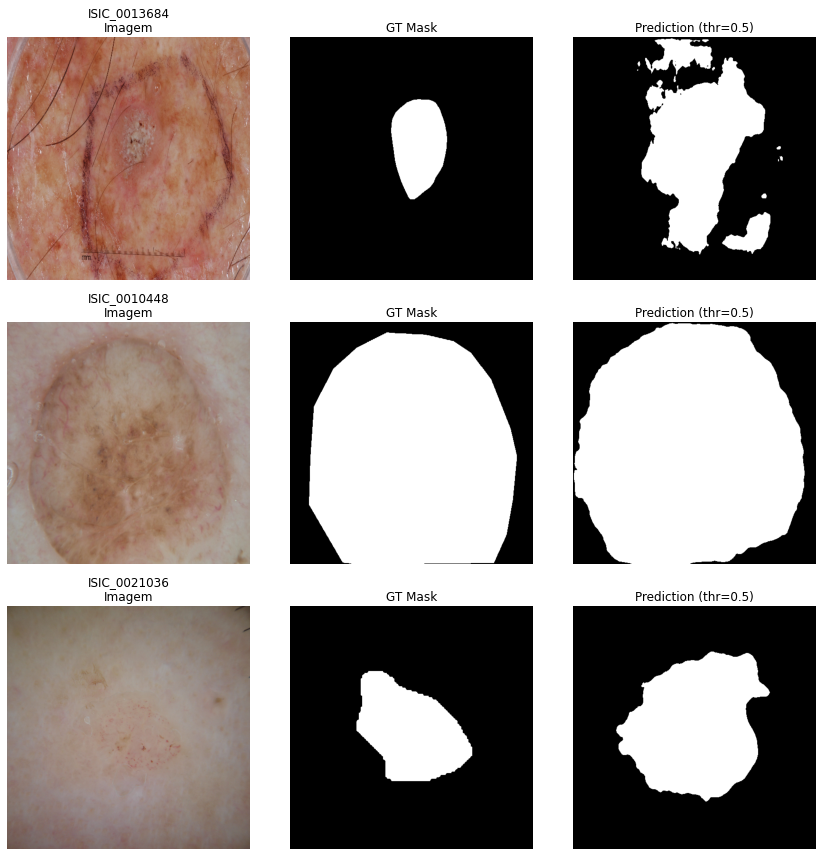

In [15]:
# ─── Visual verification of predictions (3 val samples) ─────────────────────
import matplotlib.pyplot as plt

sample_ids_vis = val_ids[:3]
fig, axes = plt.subplots(len(sample_ids_vis), 3, figsize=(12, 4 * len(sample_ids_vis)))

for i, img_id in enumerate(sample_ids_vis):
    img  = cv2.cvtColor(cv2.imread(os.path.join(img_dir, f'{img_id}.png')), cv2.COLOR_BGR2RGB)
    gt   = cv2.imread(os.path.join(mask_dir, '0', f'{img_id}.png'), cv2.IMREAD_GRAYSCALE)
    npz  = np.load(os.path.join(val_out_dir, f'{img_id}.npz'))
    p_hat = npz['p_hat'][0]                          # (H, W) ∈ [0, 1]
    pred  = (p_hat > 0.5).astype(np.uint8) * 255

    axes[i, 0].imshow(img);  axes[i, 0].set_title(f'{img_id}\nImage'); axes[i, 0].axis('off')
    axes[i, 1].imshow(gt,   cmap='gray'); axes[i, 1].set_title('GT Mask'); axes[i, 1].axis('off')
    axes[i, 2].imshow(pred, cmap='gray'); axes[i, 2].set_title('Prediction (thr=0.5)'); axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(config['models_dir'], 'val_predictions_sample.png'), dpi=120)
plt.show()